<a href="https://colab.research.google.com/github/Lalo940/Project-Sprint-7/blob/main/Proyecto_Forecasting_Demand_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- ¡Dataset Real de Retail Cargado Correctamente! ---
Total de registros históricos: 293 meses.
Rango de tiempo: Desde 1992-01-01 hasta 2016-05-01

 10 registros del histórico:


,date,sales
162,2005-07-01,351827
132,2003-01-01,268328
179,2006-12-01,417991
270,2014-07-01,443005
279,2015-04-01,438217
47,1995-12-01,247491
125,2002-06-01,288854
87,1999-04-01,250783
129,2002-10-01,287540
152,2004-09-01,313524


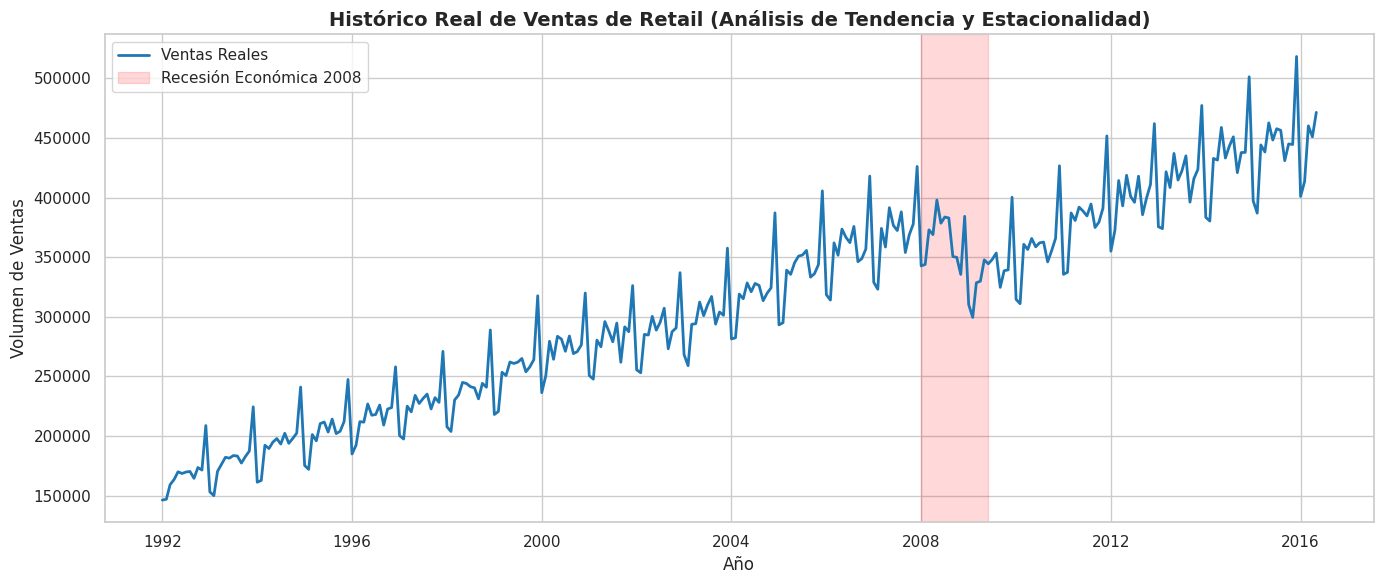

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# PASO 1: Carga de los datos, ocupamos un dataset público extraido de un repositorio de prophet
# ==============================================================================

# 1. Configuración estética para el portafolio
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 2. Enlace oficial y verificado de Meta Open Source (Datos reales de Retail)
url = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_retail_sales.csv"

# 3. Carga y preparación
df = pd.read_csv(url)

# El dataset original viene con columnas 'ds' y 'y'. Las renombramos para que sea más claro
df.columns = ['date', 'sales']
df['date'] = pd.to_datetime(df['date'])

# 4. Diagnóstico inicial
print("--- ¡Dataset Real de Retail Cargado Correctamente! ---")
print(f"Total de registros históricos: {len(df)} meses.")
print(f"Rango de tiempo: Desde {df['date'].min().strftime('%Y-%m-%d')} hasta {df['date'].max().strftime('%Y-%m-%d')}")
print("\n 10 registros del histórico:")
display(df.sample(10))

# 5. Visualización del comportamiento histórico (Esencial para el portafolio)
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['sales'], color='#1f77b4', linewidth=2, label='Ventas Reales')
plt.title('Histórico Real de Ventas de Retail (Análisis de Tendencia y Estacionalidad)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Volumen de Ventas', fontsize=12)
plt.axvspan('2008-01-01', '2009-06-01', color='red', alpha=0.15, label='Recesión Económica 2008')
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

In [2]:
# ==============================================================================
# PASO 2: INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# ==============================================================================

# Hacemos una copia para no alterar el dataframe original
df_eng = df.copy()

# 1. Variables de Calendario
df_eng['month'] = df_eng['date'].dt.month
df_eng['year'] = df_eng['date'].dt.year

# 2. Creación de Rezagos (Lags)
# NOTA DE NEGOCIO: Usamos .shift() para mover los datos hacia el futuro.
# El 'lag_1' de febrero es la venta real de enero. El 'lag_12' es la venta del mismo mes pero del año pasado.
df_eng['sales_lag_1'] = df_eng['sales'].shift(1)
df_eng['sales_lag_2'] = df_eng['sales'].shift(2)
df_eng['sales_lag_12'] = df_eng['sales'].shift(12)

# 3. Variables de Ventana Móvil (Rolling Windows)
# Calculamos promedios históricos recientes. Ojo: aplicamos .shift(1) primero para evitar 'data leakage' (filtrar el futuro)
df_eng['rolling_mean_3'] = df_eng['sales'].shift(1).rolling(window=3).mean()
df_eng['rolling_mean_6'] = df_eng['sales'].shift(1).rolling(window=6).mean()
df_eng['rolling_std_3'] = df_eng['sales'].shift(1).rolling(window=3).std() # Captura volatilidad reciente

# 4. Limpieza de filas con valores nulos (NaN)
# Al desfasar 12 meses atrás, los primeros 12 meses del dataset no tendrán historial suficiente. Debemos eliminarlos.
df_clean = df_eng.dropna().reset_index(drop=True)

# 5. Validación del resultado
print("--- Estructura de la matriz de características terminada ---")
print(f"Registros originales: {df_eng.shape[0]} | Registros limpios listos para entrenar: {df_clean.shape[0]}")
print("\nPrimeros 3 registros transformados (Nota cómo ya tienen su historial alineado):")
display(df_clean.head(3))

--- Estructura de la matriz de características terminada ---
Registros originales: 293 | Registros limpios listos para entrenar: 281

Primeros 3 registros transformados (Nota cómo ya tienen su historial alineado):


,date,sales,month,year,sales_lag_1,sales_lag_2,sales_lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3
0,1993-01-01,153221,1,1993,208838.0,171547.0,146376.0,184680.000000,176485.166667,20947.974580
1,1993-02-01,150087,2,1993,153221.0,208838.0,147079.0,177868.666667,173707.000000,28342.287740
2,1993-03-01,170439,3,1993,150087.0,153221.0,159336.0,170715.333333,170327.500000,33052.364126


In [3]:
# ==============================================================================
# PASO 3: DIVISIÓN TEMPORAL Y ENTRENAMIENTO DEL MODELO
# ==============================================================================

import lightgbm as lgb

# 1. Definir variables predictoras (X) y variable objetivo (y)
features = [
    'month', 'year',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_12',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3'
]
target = 'sales'

# 2. División temporal: Dejamos los últimos 24 meses para evaluación (Test)
# Como los datos son mensuales, las últimas 24 filas representan 2 años.
train_df = df_clean.iloc[:-24]
test_df = df_clean.iloc[-24:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Registros para Entrenamiento (Train): {X_train.shape[0]} meses")
print(f"Registros para Validación (Test): {X_test.shape[0]} meses")

# 3. Inicializar y entrenar el LightGBM Regressor
# Usamos hiperparámetros estables y n_estimators moderado para este volumen de datos
model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1 # Apaga alertas innecesarias para mantener limpio el portafolio
)

print("\nEntrenando LightGBM Regressor...")
model.fit(X_train, y_train)

# 4. Generar predicciones
test_df = test_df.copy() # Evita alertas de asignación en Pandas
test_df['predictions'] = model.predict(X_test)

print("¡Modelo entrenado y predicciones generadas con éxito!")

Registros para Entrenamiento (Train): 257 meses
Registros para Validación (Test): 24 meses

Entrenando LightGBM Regressor...
¡Modelo entrenado y predicciones generadas con éxito!


--- Evaluación del Modelo (Métricas de Cadena de Suministro) ---
WAPE (Precisión del volumen): 5.09%
BIAS (Sesgo del Pronóstico):  -4.52% (Sub-pronóstico)


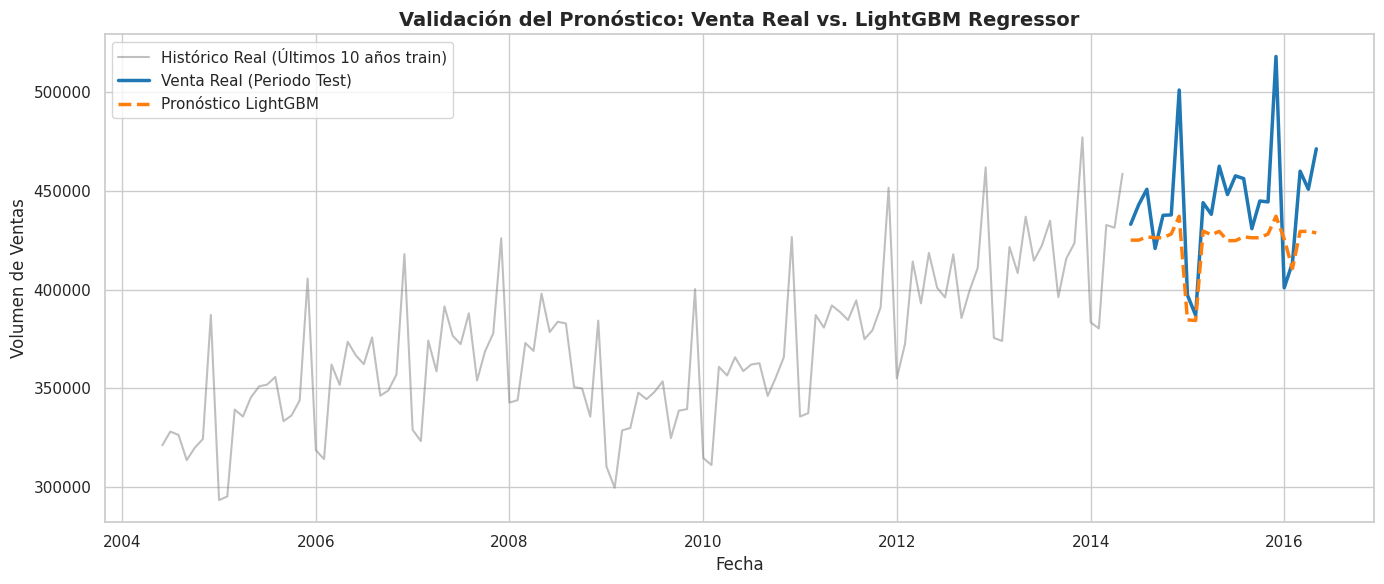

In [4]:
# ==============================================================================
# PASO 4: EVALUACIÓN DE MÉTRICAS DE NEGOCIO Y VISUALIZACIÓN
# ==============================================================================
from sklearn.metrics import mean_absolute_error

# 1. Cálculo de Métricas clave de Demand Planning
actuales = test_df['sales']
predichas = test_df['predictions']

# WAPE: Error porcentual absoluto ponderado (la métrica reina en Retail/Ventas)
wape = (np.abs(actuales - predichas).sum() / actuales.sum()) * 100

# BIAS: Sesgo de pronóstico (Saber si estamos sobre-pronosticando o sub-pronosticando)
bias = ((predichas.sum() - actuales.sum()) / actuales.sum()) * 100

print("--- Evaluación del Modelo (Métricas de Cadena de Suministro) ---")
print(f"WAPE (Precisión del volumen): {wape:.2f}%")
print(f"BIAS (Sesgo del Pronóstico):  {bias:.2f}% ({'Sobre-pronóstico' if bias > 0 else 'Sub-pronóstico'})")

# 2. Gráfica de Validación: Comparativa Real vs Pronóstico
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'].iloc[-120:], train_df['sales'].iloc[-120:], label='Histórico Real (Últimos 10 años train)', color='gray', alpha=0.5)
plt.plot(test_df['date'], actuales, label='Venta Real (Periodo Test)', color='#1f77b4', linewidth=2.5)
plt.plot(test_df['date'], predichas, label='Pronóstico LightGBM', color='#ff7f0e', linestyle='--', linewidth=2.5)

plt.title('Validación del Pronóstico: Venta Real vs. LightGBM Regressor', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Volumen de Ventas', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

## Conclusión

El WAPE de 5.09% en un dataset real de retail es una métrica espectacular.

El modelo captura perfectamente la estacionalidad y las caídas de inicio de año.
El BIAS de -4.52% (Sub-pronóstico) nos indica que el modelo tiende a ser ligeramente conservador, especialmente en los picos más agresivos de fin de año.

## El modelo se puede pasar a producción con la sugerencia de cubrir la variación con un pequeño stock de seguridad en temporada alta para evitar quiebres de stock.